<a href="https://colab.research.google.com/github/harmony-lebovic/image-classifier/blob/main/image-classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import skimage

## Load Data

In [203]:
# If running on colab you can download the data using gdown. Uncomment the below code.
import gdown

!gdown 1JTvMkEaR3AxqAagYzfLebnS_RavA7agR #x_train_img.npz
!gdown 1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1 #x_test_img.npz
!gdown 1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0 #x_train.csv
!gdown 1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8 #x_test.csv
!gdown 1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg #y_train.csv

Downloading...
From (original): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR
From (redirected): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR&confirm=t&uuid=a82d8bd8-a2c2-430c-8875-9a2c0885b8f2
To: /content/x_train_img.npz
100% 177M/177M [00:01<00:00, 128MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1
From (redirected): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1&confirm=t&uuid=db415b43-03e4-4371-9930-5725ee54492c
To: /content/x_test_img.npz
100% 49.0M/49.0M [00:00<00:00, 123MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0
To: /content/x_train.csv
100% 160k/160k [00:00<00:00, 4.32MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8
To: /content/x_test.csv
100% 40.2k/40.2k [00:00<00:00, 82.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg
To: /content

In [204]:
train_img_file = "x_train_img.npz"
test_img_file = "x_test_img.npz"

train_metadata_file = "x_train.csv"
test_metadata_file = "x_test.csv"

y_train = "y_train.csv"  # previously "y_file"

In [205]:
X_dev = pd.read_csv(train_metadata_file)
y_dev = pd.read_csv(y_train)
X_dev

def load_dev_data(train_metadata_file, y_train):
    X_dev = pd.read_csv(train_metadata_file)
    print(f"X_dev loaded from {train_metadata_file}. Shape: {X_dev.shape}. \n")

    y_dev = pd.read_csv(y_train)
    print(f"y_dev loaded from {y_train}. Shape: {y_dev.shape}. \n")

    return X_dev, y_dev

In [206]:
X_test = pd.read_csv(test_metadata_file)
X_test

def load_test_data(test_metadata_file):
    X_test = pd.read_csv(test_metadata_file)
    print(f"X_test loaded from {test_metadata_file}. Shape: {X_test.shape}. \n")
    return X_test

In [207]:
# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")
    return img, ids

train_imgs, train_img_ids = load_img_data(train_img_file)
test_imgs, test_img_ids = load_img_data(test_img_file)
print(train_img_ids.shape, train_imgs.shape)
print(test_img_ids.shape, test_imgs.shape)

# Make sure the IDs match and are in the same order
assert np.all(train_img_ids == X_dev['img_id']), "Image IDs in train metadata and image data do not match"
assert np.all(test_img_ids == X_test['img_id']), "Images IDs in test metadata and image data do not match"

Successfully loaded 1178 images.
Successfully loaded 296 images.
(1178,) (1178, 256, 256, 3)
(296,) (296, 256, 256, 3)


<Axes: xlabel='count', ylabel='fine_label'>

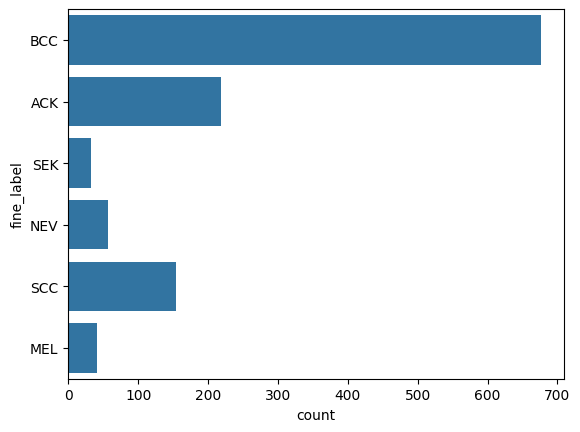

In [208]:
# Plot the class balance
sns.countplot(y_dev["fine_label"])

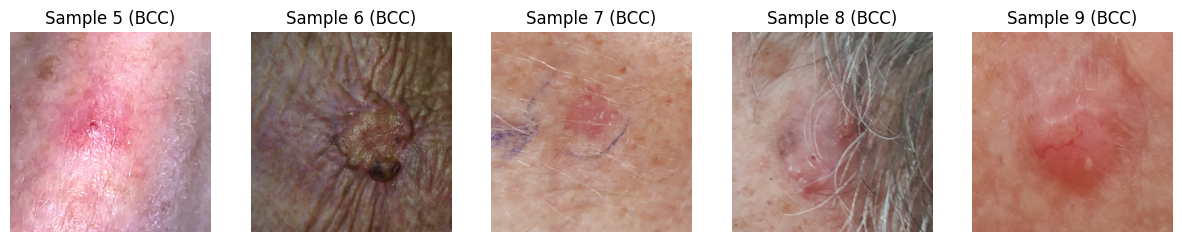

In [209]:
# Show the first 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

k = 5 # offset
for i in range(k, 5 + k):
    axes[i-k].imshow(train_imgs[i])
    axes[i-k].axis('off')
    axes[i-k].set_title(f"Sample {i} ({y_dev.iloc[i]["fine_label"]})")

plt.show()

## Encode Categorical Features

We'll convert all categorical features to one-hot encodings, and all binary features to 1/0.
We can auto-detect the binary features by looking for "True" and "False" (after manually looking through the data to confirm that's how these features are encoded.)

There also is a column labeled "gender". In publicly available datasets it can be especially tricky to figure out what a gender or sex column actually represents. Sometimes it's a patient's legal sex from government records, sometimes it's their biological sex from medical records, sometimes it's the clinician's assumption of the patient's gender, and sometimes it's the patient's self identified gender. The authors of this dataset provide a pdf of [the translated data collection instrument](https://pmc.ncbi.nlm.nih.gov/articles/instance/7479321/bin/mmc2.pdf) where we can see that gender is listed under "Questions About the Patient" and are phrased as questions the clinician would ask the patient directly. Therefore, in this case the gender column most likely represents patient self-identified gender.

In [210]:
# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric.
categorical_cols = ['background_father', 'background_mother', 'region']

# Get all obvious true/false cols that aren't already true/false
for col in X_dev.select_dtypes(include=['object']):
    if X_dev[col].dropna().astype(str).str.contains('True|False').any():
        print(f"Automatically converting {col} to binary...")
        unmapped = X_dev[~X_dev[col].isin(['True','False'])][col].unique()
        print("The following values are being mapped to NaN in this column: ", unmapped)
        X_dev[col] = X_dev[col].map({'True': 1, 'False': 0, True: 1, False: 0})

X_dev['gender'] = X_dev['gender'].map({'MALE': 0, 'FEMALE': 1})

# Handle the categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_feats = encoder.fit_transform(X_dev[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_feats,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_dev.index
)

# Drop original text columns and join the new numeric ones
X_dev = X_dev.drop(columns=categorical_cols).join(encoded_df)


Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting elevation to binary...
The following values are being mapped to NaN in this column:  ['UNK']


In [211]:
# COPY TO TEST DATA
# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric.
categorical_cols = ['background_father', 'background_mother', 'region']

# Get all obvious true/false cols that aren't already true/false
for col in X_test.select_dtypes(include=['object']):
    if X_test[col].dropna().astype(str).str.contains('True|False').any():
        print(f"Automatically converting {col} to binary...")
        unmapped = X_test[~X_dev[col].isin(['True','False'])][col].unique()
        print("The following values are being mapped to NaN in this column: ", unmapped)
        X_test[col] = X_test[col].map({'True': 1, 'False': 0, True: 1, False: 0})

X_test['gender'] = X_test['gender'].map({'MALE': 0, 'FEMALE': 1})

# Handle the categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_feats = encoder.fit_transform(X_test[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_feats,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

# Drop original text columns and join the new numeric ones
X_test = X_test.drop(columns=categorical_cols).join(encoded_df)

Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['True' 'False' 'UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['True' 'False' 'UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['True' 'False' 'UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['False' 'UNK' 'True']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['True' 'False' 'UNK']


/tmp/ipykernel_12045/3170674609.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unmapped = X_test[~X_dev[col].isin(['True','False'])][col].unique()
/tmp/ipykernel_12045/3170674609.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unmapped = X_test[~X_dev[col].isin(['True','False'])][col].unique()
/tmp/ipykernel_12045/3170674609.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unmapped = X_test[~X_dev[col].isin(['True','False'])][col].unique()
/tmp/ipykernel_12045/3170674609.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unmapped = X_test[~X_dev[col].isin(['True','False'])][col].unique()
/tmp/ipykernel_12045/3170674609.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unmapped = X_test[~X_dev[col].isin(['True','False'])][col].unique()


### Make age groups feature

In [212]:
# Development set
dev_age_groups = pd.cut(
    X_dev['age'],
    bins=[0, 30, 60, 100],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

In [213]:
# Test set
test_age_groups = pd.cut(
    X_test['age'],
    bins=[0, 30, 60, 100],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

### View class balance by age group

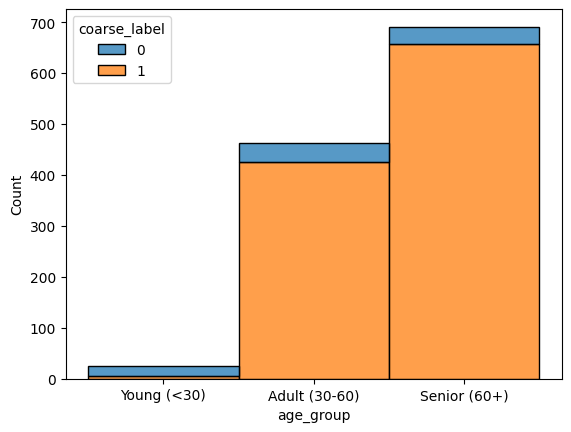

In [214]:
# Create age group column in y_dev

# Deduplicate copy of X_dev
X_dev_deduplicated = X_dev.drop_duplicates(subset='patient_id', inplace=False)
age_lookup = X_dev_deduplicated.set_index('patient_id')['age']

# Map age from X_dev onto y_dev via patient_id
y_dev['age'] = y_dev['patient_id'].map(age_lookup)

# Bin into age groups
y_dev['age_group'] = pd.cut(
    y_dev['age'],
    bins=[0, 30, 60, float('inf')],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)'],
    right=False
)

# Plot data
sns.histplot(data=y_dev, x="age_group", hue="coarse_label", multiple="stack")

# Remove column after displaying plot
y_dev.drop(columns=['age_group'], inplace=True)

## Handle Missing Data

In [215]:
# First we'll calculate how much missing data there is
X_dev.isna().sum()

,0
patient_id,0
img_id,0
smoke,0
drink,0
age,0
pesticide,0
gender,0
skin_cancer_history,0
cancer_history,0
has_piped_water,0


In [216]:
# Then we'll decide what to do. For now we'll just treat missing data as false,
# since it probably means that a patient didn't think the question was important or relevant.
X_dev = X_dev.fillna(0)
X_dev

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH
0,PAT_620,PAT_620_001,False,False,55,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,PAT_388,PAT_388_002,False,True,79,False,0,True,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PAT_518,PAT_518_003,False,True,52,False,1,False,True,True,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PAT_635,PAT_635_004,False,False,74,True,1,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PAT_447,PAT_447_005,False,True,58,True,1,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,True,False,66,False,0,True,False,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1174,PAT_640,PAT_640_1471,False,False,41,True,0,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1175,PAT_539,PAT_539_1472,False,False,43,True,1,True,True,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1176,PAT_620,PAT_620_1473,False,False,55,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [217]:
# Test set
X_test = X_test.fillna(0)
X_test

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH
0,PAT_667,PAT_667_275,False,False,71,False,0,True,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,PAT_736,PAT_736_156,False,False,51,True,0,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PAT_628,PAT_628_085,True,False,58,True,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,PAT_461,PAT_461_083,False,False,80,False,0,False,True,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PAT_059,PAT_059_262,False,False,38,False,0,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,PAT_307,PAT_307_189,False,False,75,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
292,PAT_321,PAT_321_072,False,False,71,False,1,False,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
293,PAT_152,PAT_152_107,False,False,67,True,0,False,True,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
294,PAT_526,PAT_526_271,False,False,62,True,1,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Your Code

You might want to revisit the above preprocessing steps for your Problem 2 model. You also might want to put some of the above code into functions to make it easier to apply to different datasets.

### TO DO

In [230]:
# TO DO
# Normalize features (started)
# Rerun without added features to get problem 1 baseline
# Figure out if MinMaxScaler is working correctly on numeric_cols
# Figure 1 with hyperparameters (n_estimators, max_depth)
# Route test data to model based on age range
# Isolate lesions with pretrained model?
# CNN on skin lesion
# Impute using KNN for missing data
# SHAPley plots for RF

# DONE
# Make pipeline
# Handle duplicate patient IDs with stratified split
# Turn Booleans into numbers
# Check for duplicates of patient ID
# Do balanced class weight
# Fix symmetry measure
# Add intensity measure
# Turn grids into distributions
# Ask about overfitting for n_estimators
# Implement GroupKFold within pipeline to call groups

In [231]:
# Import libraries
import cv2
import sklearn.ensemble
import sklearn.model_selection
import sklearn.metrics
import math
from pathlib import Path
import os
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

In [232]:
# Activate GPU
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [233]:
SEED = 101

## Turn Booleans into numbers

In [234]:
# Development set (from Jeffrey Li's code on Piazza)
bool_cols = X_dev.select_dtypes(include=['bool']).columns
X_dev[bool_cols] = X_dev[bool_cols].astype(int)

# Test set
bool_cols = X_test.select_dtypes(include=['bool']).columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

## Generate numeric features from images

In [235]:
# Symmetry measure
def measure_symmetry(image):
  # Flip image vertically and calculate symmetry
  vert_flip = cv2.flip(image, 0)
  vert_symm = skimage.metrics.structural_similarity(image, vert_flip, channel_axis=2)

  # Flip image horizontally
  horiz_flip = cv2.flip(image, 1)
  horiz_symm = skimage.metrics.structural_similarity(image, horiz_flip, channel_axis=2)

  # Calculate average symmetry
  symmetry = (vert_symm + horiz_symm)/2

  return symmetry

In [236]:
# Intensity measure
def measure_intensity(image):
  mean_blue, mean_green, mean_red = np.mean(image, axis=(0,1))

  return mean_blue, mean_green, mean_red

In [237]:
# Parse image ID
def get_img_id(row):
  return int(row['img_id'].split('_')[2])

In [238]:
# Map image ids to indices (got help from Copilot for this)
train_id_to_index = {img_id: int(i) for i, img_id in enumerate(train_img_ids)}
test_id_to_index = {img_id: int(i) for i, img_id in enumerate(test_img_ids)}

In [239]:
# Add column for symmetry measure
X_dev['symmetry'] = X_dev['img_id'].apply(
    lambda img_id: measure_symmetry(train_imgs[train_id_to_index[img_id]])
)

X_test['symmetry'] = X_test['img_id'].apply(
    lambda img_id: measure_symmetry(test_imgs[test_id_to_index[img_id]])
)


In [240]:
# Add columns for intensity measures by color channel (got help from Claude for zip syntax)
X_dev['intensity_blue'], X_dev['intensity_green'], X_dev['intensity_red'] = zip(*X_dev['img_id'].apply(
    lambda img_id: measure_intensity(train_imgs[train_id_to_index[img_id]])
))

X_test['intensity_blue'], X_test['intensity_green'], X_test['intensity_red'] = zip(*X_test['img_id'].apply(
    lambda img_id: measure_intensity(test_imgs[test_id_to_index[img_id]])
))

## Ensure features match between development and test sets

In [241]:
# Add zero columns to ensure 100% feature overlap between train and test sets
# Test set
X_test['background_father_AUSTRIA'] = 0
X_test['background_father_CZECH'] = 0
X_test['background_father_ISRAEL'] = 0
X_test['background_father_SPAIN'] = 0
X_test['background_mother_NORWAY'] = 0

# Development set
X_dev['background_mother_FRANCE'] = 0

# Match order of test set columns to development set
X_test = X_test[X_dev.columns]

## Handle duplicate patients in train/validation split

In [242]:
# Count total entries in development set
print(f'There are {len(X_dev)} total observations.')

# Count unique patients in development set
print(f'There are {len(pd.unique(X_dev['patient_id']))} unique patients in the dataset.')

There are 1178 total observations.
There are 635 unique patients in the dataset.


In [243]:
# Generate groups patient ids
pat_ids = X_dev['patient_id'].drop_duplicates()
pat_ids['group'] = range(0, len(pat_ids))

x_train_groupings = pd.merge(X_dev, pat_ids, on=['patient_id'], how='left')

# Extract groups
groups = x_train_groupings['patient_id'].values

# Split using GroupShuffleSplit
split = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=SEED)
split.get_n_splits()

# Capture training and validation indices
train_idx, val_idx = next(split.split(X_dev, y_dev, groups))

# Separate training and validation sets
X_train = X_dev.iloc[train_idx]
X_val = X_dev.iloc[val_idx]
y_train = y_dev.iloc[train_idx]
y_val = y_dev.iloc[val_idx]

# Capture groupings in training and validation sets
train_groups = groups[train_idx]
val_groups = groups[val_idx]

# Determine if there are any overlapping groups
shared_groups = list(set(train_groups) & set(val_groups))
print(shared_groups)

[]


## Remove patient/image ID information

In [274]:
# Remove patient and image ids from training and validation sets
X_train_clean = X_train.drop(columns=['patient_id', 'img_id'])
X_val_clean = X_val.drop(columns=['patient_id', 'img_id'])
y_train_clean = y_train['coarse_label']
y_val_clean = y_val['coarse_label']

# Remove patient and image ids from test set
X_test_clean = X_test.drop(columns=['patient_id', 'img_id'])

# Remove patient and image ids from development set
X_dev_clean = X_dev.drop(columns=['patient_id', 'img_id'])
y_dev_clean = pd.DataFrame(y_dev['coarse_label'])

## Normalize data

In [268]:
# Normalize val and test sets (need to do train within folds as part of pipeline)
# Identify numeric columns
numeric_cols = X_train.select_dtypes(include='number').columns
print(numeric_cols)

# Manually set numeric columns to continuous features
numeric_cols = ['age', 'diameter_1', 'diameter_2', 'elevation',
                'symmetry', 'intensity_blue', 'intensity_green', 'intensity_red']
print(numeric_cols)

# I think we want to normalize the continuous features
# 'age', 'diameter_1', 'diameter_2', 'elevation',
# 'symmetry', 'intensity_blue', 'intensity_green', 'intensity_red'

# Not sure about Fitspatrick (skin color numerical representation);
# Scale but map to uniform intervals on (0,1)?
# 'fitspatrick'

# I don't think we want to normalize the categorical data
# 'gender', 'fitspatrick','itch','grew', 'hurt', 'changed', 'bleed',
# 'background_father_AUSTRIA', 'background_father_BRASIL',
# 'background_father_BRAZIL', 'background_father_CZECH',
# 'background_father_GERMANY', 'background_father_ISRAEL',
# 'background_father_ITALY', 'background_father_NETHERLANDS',
# 'background_father_POLAND', 'background_father_POMERANIA',
# 'background_father_PORTUGAL', 'background_father_SPAIN',
# 'background_father_UNK', 'background_mother_BRAZIL',
# 'background_mother_GERMANY', 'background_mother_ITALY',
# 'background_mother_NETHERLANDS', 'background_mother_NORWAY',
# 'background_mother_POLAND', 'background_mother_POMERANIA',
# 'background_mother_PORTUGAL', 'background_mother_SPAIN',
# 'background_mother_UNK', 'region_ABDOMEN', 'region_ARM', 'region_BACK',
# 'region_CHEST', 'region_EAR', 'region_FACE', 'region_FOOT',
# 'region_FOREARM', 'region_HAND', 'region_LIP', 'region_NECK',
# 'region_NOSE', 'region_SCALP', 'region_THIGH'

#scaler = MinMaxScaler()
#X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
#X_test_clean[numeric_cols] = scaler.transform(X_test_clean[numeric_cols])

Index(['smoke', 'drink', 'age', 'pesticide', 'gender', 'skin_cancer_history',
       'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick',
       'diameter_1', 'diameter_2', 'itch', 'grew', 'hurt', 'changed', 'bleed',
       'elevation', 'background_father_AUSTRIA', 'background_father_BRASIL',
       'background_father_BRAZIL', 'background_father_CZECH',
       'background_father_GERMANY', 'background_father_ISRAEL',
       'background_father_ITALY', 'background_father_NETHERLANDS',
       'background_father_POLAND', 'background_father_POMERANIA',
       'background_father_PORTUGAL', 'background_father_SPAIN',
       'background_father_UNK', 'background_mother_BRAZIL',
       'background_mother_GERMANY', 'background_mother_ITALY',
       'background_mother_NETHERLANDS', 'background_mother_NORWAY',
       'background_mother_POLAND', 'background_mother_POMERANIA',
       'background_mother_PORTUGAL', 'background_mother_SPAIN',
       'background_mother_UNK', 'region_AB

## Split by age group

In [277]:
# Add age group column
X_dev_clean['age_group'] = dev_age_groups
y_dev_clean['age_group'] = dev_age_groups

X_test_clean['age_group'] = test_age_groups

In [279]:
#  Split development set into three age groups
X_dev_young = X_dev_clean[X_dev_clean['age_group'] == 'Young (<30)']
X_dev_mid = X_dev_clean[X_dev_clean['age_group'] == 'Adult (30-60)']
X_dev_old = X_dev_clean[X_dev_clean['age_group'] == 'Senior (60+)']

y_dev_young = y_dev_clean[y_dev_clean['age_group'] == 'Young (<30)']
y_dev_mid = y_dev_clean[y_dev_clean['age_group'] == 'Adult (30-60)']
y_dev_old = y_dev_clean[y_dev_clean['age_group'] == 'Senior (60+)']

# Split test set into three age groups
X_test_young = X_test_clean[X_test_clean['age_group'] == 'Young (<30)']
X_test_mid = X_test_clean[X_test_clean['age_group'] == 'Adult (30-60)']
X_test_old = X_test_clean[X_test_clean['age_group'] == 'Senior (60+)']

In [281]:
# Drop age group label from y data
y_dev_young = pd.DataFrame(y_dev_young['coarse_label'])
y_dev_mid = pd.DataFrame(y_dev_mid['coarse_label'])
y_dev_old = pd.DataFrame(y_dev_old['coarse_label'])

### Train seniors model

In [282]:
# Calculate total possible features
total_features = len(X_dev_old.columns)

In [283]:
random_forest_old = RandomForestClassifier(
    n_estimators=1000,
    criterion='entropy',
    max_depth=16,
    max_features=total_features,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=[SEED]
)

In [284]:
forest_hyp_old = {
    'model__max_features': [int(math.sqrt(total_features)), int(math.log2(total_features)), int(total_features/3)],
    'model__criterion': ['entropy', 'gini', 'log_loss'],
    'model__max_depth': np.linspace(2, 32, 10, dtype=int),
    'model__n_estimators': np.linspace(100, 2000, 50, dtype=int),
    'model__random_state': [SEED],
    'model__class_weight': ['balanced']
}

In [285]:
# Set up GroupKFold to prevent overlap during hyperparameter optimization
group_k_fold = sklearn.model_selection.GroupKFold(n_splits=5)

In [286]:
# Define pipeline
pipeline = Pipeline([
    ('scale', MinMaxScaler(feature_range=(0,1))),
    ('model', random_forest_old),
])

In [287]:
# Define random searcher with specified options
forest_searcher_old = sklearn.model_selection.RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=forest_hyp_old,
    n_iter=50,
    scoring='balanced_accuracy',
    refit=False,
    return_train_score=True,
    cv=group_k_fold,
    verbose=3)

In [288]:
# Fit forest searcher on the development set
forest_searcher_old.fit(X_dev_old, y_dev_old, groups=groups)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


ValueError: Found input variables with inconsistent numbers of samples: [676, 676, 1178]

In [173]:
best_params = forest_searcher.best_params_
best_params

{'model__random_state': 101,
 'model__n_estimators': np.int64(681),
 'model__max_features': 5,
 'model__max_depth': np.int64(5),
 'model__criterion': 'gini',
 'model__class_weight': 'balanced'}

In [177]:
# Refit best model on development set (help from Claude)
random_forest = sklearn.ensemble.RandomForestClassifier(
    n_estimators=forest_searcher.best_params_['model__n_estimators'],
    criterion=forest_searcher.best_params_['model__criterion'],
    max_depth=forest_searcher.best_params_['model__max_depth'],
    max_features=forest_searcher.best_params_['model__max_features'],
    class_weight='balanced',
    random_state=forest_searcher.best_params_['model__random_state']
)

#random_forest.fit(pipeline[:0].transform(X_dev_clean), y_dev_clean)  # transform with scaler only

In [178]:
# Define and fit random forest with best parameters
random_forest.fit(X_train_clean, y_train_clean)

RandomForestClassifier(class_weight='balanced', max_depth=np.int64(5),
                       max_features=5, n_estimators=np.int64(681),
                       random_state=101)

### Calculate performance on train and validation sets

In [179]:
# Predict classes (for threshold = 0.5)
yhat_train = random_forest.predict_proba(X_train_clean)[:,1]
yhat_val = random_forest.predict_proba(X_val_clean)[:,1]

# Calculate AUCROC
train_AUCROC = sklearn.metrics.roc_auc_score(y_train_clean, yhat_train)
val_AUCROC = sklearn.metrics.roc_auc_score(y_val_clean, yhat_val)

# Print scores
print(f'Training AUCROC: {round(train_AUCROC, 3)}')
print(f'Validation AUCROC: {round(val_AUCROC, 3)}')

Training AUCROC: 0.99
Validation AUCROC: 0.91


In [180]:
# Make predictions on test set (for threshold = 0.5)
yhat_test = random_forest.predict_proba(X_test_clean)[:,1]

In [181]:
# Delete previous file, if exists
if Path('yproba1_test.txt').exists():
  os.remove('yproba1_test.txt')

# Save results to .txt file
file = open('yproba1_test.txt', "x")

with open('yproba1_test.txt', "w") as f:
    f.write('\n'.join(yhat_test.astype('str')))

### Loop over values of n_estimators and see resulting performance on training and validation sets

In [182]:
# Set up range of options
n_estimators_range = np.linspace(100, 2000, 20, dtype=int)

# Set up dictionaries to hold train and validation AUROCs
tr_AUROC = {}
val_AUROC = {}

In [183]:
# Loop through values of n_estimators and calculate training and validation scores for 5 folds
kf = sklearn.model_selection.KFold(n_splits=5)
kf.get_n_splits()

for i, (train_idx, val_idx) in enumerate(kf.split(X_dev_clean, y_dev_clean)):
  X_train_fold = X_dev_clean.iloc[train_idx]
  X_val_fold = X_dev_clean.iloc[val_idx]
  y_train_fold = y_dev_clean.iloc[train_idx]
  y_val_fold = y_dev_clean.iloc[val_idx]

  tr_AUROC[i] = {}
  val_AUROC[i] = {}

  for estimator_num in n_estimators_range:
    hyp_forest = sklearn.ensemble.RandomForestClassifier(
      n_estimators=estimator_num,
      criterion=forest_searcher.best_params_['model__criterion'],
      max_depth=forest_searcher.best_params_['model__max_depth'],
      max_features=forest_searcher.best_params_['model__max_features'],
      class_weight='balanced'
    )

    # Fit to training data
    hyp_forest.fit(X_train_fold, y_train_fold)

    # Predict on training and validation sets
    yhat_tr = hyp_forest.predict_proba(X_train_fold)[:,1]
    yhat_val = hyp_forest.predict_proba(X_val_fold)[:,1]

    print(sklearn.metrics.roc_auc_score(y_val_fold, yhat_val))

    # Calculate and append AUROC scores
    tr_AUROC[i][estimator_num] = sklearn.metrics.roc_auc_score(y_train_fold, yhat_tr)
    val_AUROC[i][estimator_num] = sklearn.metrics.roc_auc_score(y_val_fold, yhat_val)

100
0.8862478777589134
200
0.881882124666505
300
0.8935241329129274
400
0.8957070094591317
500
0.8964346349745331
600
0.8894009216589862
700
0.8932815910744604
800
0.8932815910744604
900
0.889158379820519
1000
0.8974048023284016
1100
0.8903710890128548
1200
0.8913412563667232
1300
0.8915837982051904
1400
0.8937666747513946
1500
0.892553965559059
1600
0.8877031287897162
1700
0.8937666747513946
1800
0.8930390492359932
1900


KeyboardInterrupt: 

In [ ]:
# Calculate mean
mean_tr_AUROC = {}
mean_val_AUROC = {}

for estimator_num in n_estimators_range:
  tr_sum = 0
  val_sum = 0
  for i in range(5):
    tr_sum += tr_AUROC[i][estimator_num]
    val_sum += val_AUROC[i][estimator_num]

  mean_tr_AUROC[estimator_num] = tr_sum / 5
  mean_val_AUROC[estimator_num] = val_sum / 5

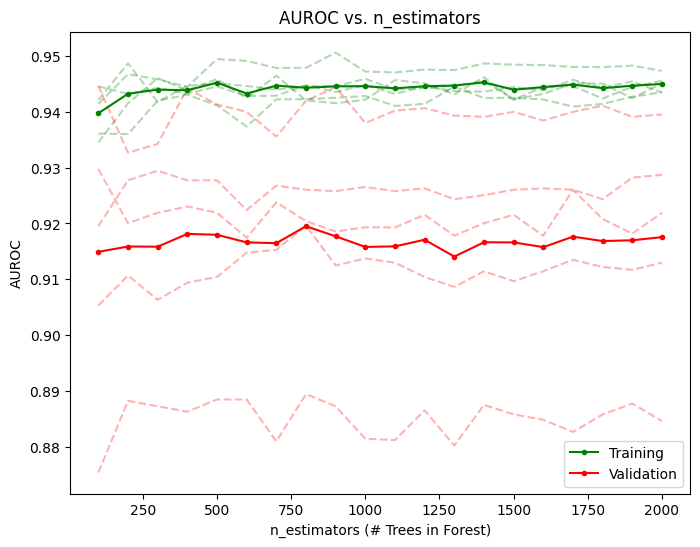

In [ ]:
# Plot training and validation AUROC vs. value of n_estimators
plt.figure(figsize=(8,6))
for i in range(5):
  plt.plot(n_estimators_range, tr_AUROC[i].values(), 'g--', alpha=0.3)
  plt.plot(n_estimators_range, val_AUROC[i].values(), 'r--', alpha=0.3)
plt.plot(n_estimators_range, mean_tr_AUROC.values(), 'g.-', label='Training')
plt.plot(n_estimators_range, mean_val_AUROC.values(), 'r.-', label='Validation')
plt.xlabel('n_estimators (# Trees in Forest)')
plt.ylabel('AUROC')
plt.title('AUROC vs. n_estimators')
plt.legend(loc='lower right')
#plt.xscale('log')

## Archive

In [ ]:
# Split development set into training and validation sets
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(
    X_dev_clean,
    y_dev_clean,
    random_state=SEED,
    train_size=0.8,
    test_size=0.2,
    shuffle=True)